# Multi-modal RAG with LangChain

## SetUp

Install the dependencies you need to run the notebook.

In [ ]:
# for linux
# !apt-get install poppler-utils tesseract-ocr libmagic-dev

# for mac
# !brew install poppler tesseract libmagic

In [1]:
%pip install -Uq "unstructured[all-docs]" lxml
%pip install -Uq chromadb tiktoken
%pip install -Uq langchain langchain-community langchain-openai langchain-groq
%pip install -Uq python_dotenv


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.49.1 requires pillow<12.0,>=8.0, but you have pillow 12.0.0 which is incompatible.


In [2]:
!pip uninstall --yes pillow

Found existing installation: pillow 12.0.0
Uninstalling pillow-12.0.0:
  Successfully uninstalled pillow-12.0.0


In [6]:
!pip install pillow==10.0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 31.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pi-heif 1.1.1 requires pillow>=11.1.0, but you have pillow 10.0.0 which is incompatible.
pikepdf 10.0.2 requires Pillow>=10.0.1, but you have pillow 10.0.0 which is incompatible.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 10.0.0 which is incompatible.


In [3]:
!pip uninstall --yes pillow pdf2image
!pip install pillow==10.0.0 pdf2image==1.16.3

Found existing installation: pdf2image 1.16.3
Uninstalling pdf2image-1.16.3:
  Successfully uninstalled pdf2image-1.16.3
  Using cached Pillow-10.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached pdf2image-1.16.3-py3-none-any.whl.metadata (6.2 kB)
Using cached Pillow-10.0.0-cp312-cp312-manylinux_2_28_x86_64.whl (3.4 MB)
Using cached pdf2image-1.16.3-py3-none-any.whl (11 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pi-heif 1.1.1 requires pillow>=11.1.0, but you have pillow 10.0.0 which is incompatible.
pikepdf 10.0.2 requires Pillow>=10.0.1, but you have pillow 10.0.0 which is incompatible.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 10.0.0 which is incompatible.


In [4]:
!apt-get install -y poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [44]:
from google.colab import userdata
import os

# os.environ['HF_ACCESS_TOKEN'] = userdata.get('HF_ACCESS_TOKEN')
# os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
# os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')

In [ ]:
# import os

# # keys for the services we will use

# os.environ["OPENAI_API_KEY"] = "sk-..."
# os.environ["GROQ_API_KEY"] = "sk-..."
# os.environ["LANGCHAIN_API_KEY"] = "sk-..."
# os.environ["LANGCHAIN_TRACING_V2"] = "true"


## Extract the data

Extract the elements of the PDF that we will be able to use in the retrieval process. These elements can be: Text, Images, Tables, etc.

### Partition PDF tables, text, and images

In [ ]:
from unstructured.partition.pdf import partition_pdf

output_path = "./content/"
file_path = "/content/pdf_to_work.pdf"

# Reference: https://docs.unstructured.io/open-source/core-functionality/chunking
chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,            # extract tables
    strategy="hi_res",                     # mandatory to infer tables

    extract_image_block_types=["Image"],   # Add 'Table' to list to extract image of tables
    # image_output_dir_path=output_path,   # if None, images and tables will saved in base64

    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage

    chunking_strategy="by_title",          # or 'basic'
    max_characters=10000,                  # defaults to 500
    combine_text_under_n_chars=2000,       # defaults to 0
    new_after_n_chars=6000,

    # extract_images_in_pdf=True,          # deprecated
)

preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

In [8]:
len(chunks)

6

In [6]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [16]:
chunks[5].to_dict()

{'type': 'CompositeElement',
 'element_id': 'a9abd4e25dcb8019f70331523ad90544',
 'text': 'TYPICAL SKETCH FOR CEMENT GODOWN\n\nSub Head : Carriage Clause : 1.7.1.2\n\nAC_orGi. SHEET OR ANY KIND OF WEATHER PROOF ROOF OAD BEARING (ALL MAX 10 BAGS DOOR PLAN\n\nA= Planks\n\nB = Wooden Battens C = 150 Dry Bricks in two Layers or Lean Cement Concrete\n\nD = 150 Consolidated Earth\n\nDrawing not to scale All Dimensions in millimetres\n\nFig. 1.1 : Typical Arrangement in Cement Godown\n\n23 SUB HEAD 1.0 : CARRIAGE OF MATERIALS',
 'metadata': {'filetype': 'application/pdf',
  'languages': ['eng'],
  'last_modified': '2025-11-22T06:14:19',
  'page_number': 9,
  'orig_elements': '...',
  'file_directory': '/content',
  'filename': 'pdf_to_work.pdf'}}

In [19]:
# Each CompositeElement containes a bunch of related elements.
# This makes it easy to use these elements together in a RAG pipeline.

chunks[5].metadata.orig_elements

In [20]:
# This is what an extracted image looks like.
# It contains the base64 representation only because we set the param extract_image_block_to_payload=True

elements = chunks[5].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': '671f4021-008d-40ee-9785-7685ab452021',
 'text': 'AC_orGi. SHEET OR ANY KIND OF WEATHER PROOF ROOF OAD BEARING (ALL MAX 10 BAGS DOOR PLAN',
 'metadata': {'detection_class_prob': 0.8375091552734375,
  'coordinates': {'points': ((np.float64(404.4246826171875),
     np.float64(486.1898193359375)),
    (np.float64(404.4246826171875), np.float64(1632.0233154296875)),
    (np.float64(1333.6551513671875), np.float64(1632.0233154296875)),
    (np.float64(1333.6551513671875), np.float64(486.1898193359375))),
   'system': 'PixelSpace',
   'layout_width': 1653,
   'layout_height': 2339},
  'last_modified': '2025-11-22T06:14:19',
  'filetype': 'PPM',
  'languages': ['eng'],
  'page_number': 9,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg'}}

### Separate extracted elements into tables, text, and images

In [21]:
# separate tables from texts
tables = []
texts = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type((chunk))):
        texts.append(chunk)

In [22]:
# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

#### Check what the images look like

In [24]:
len(images)

1

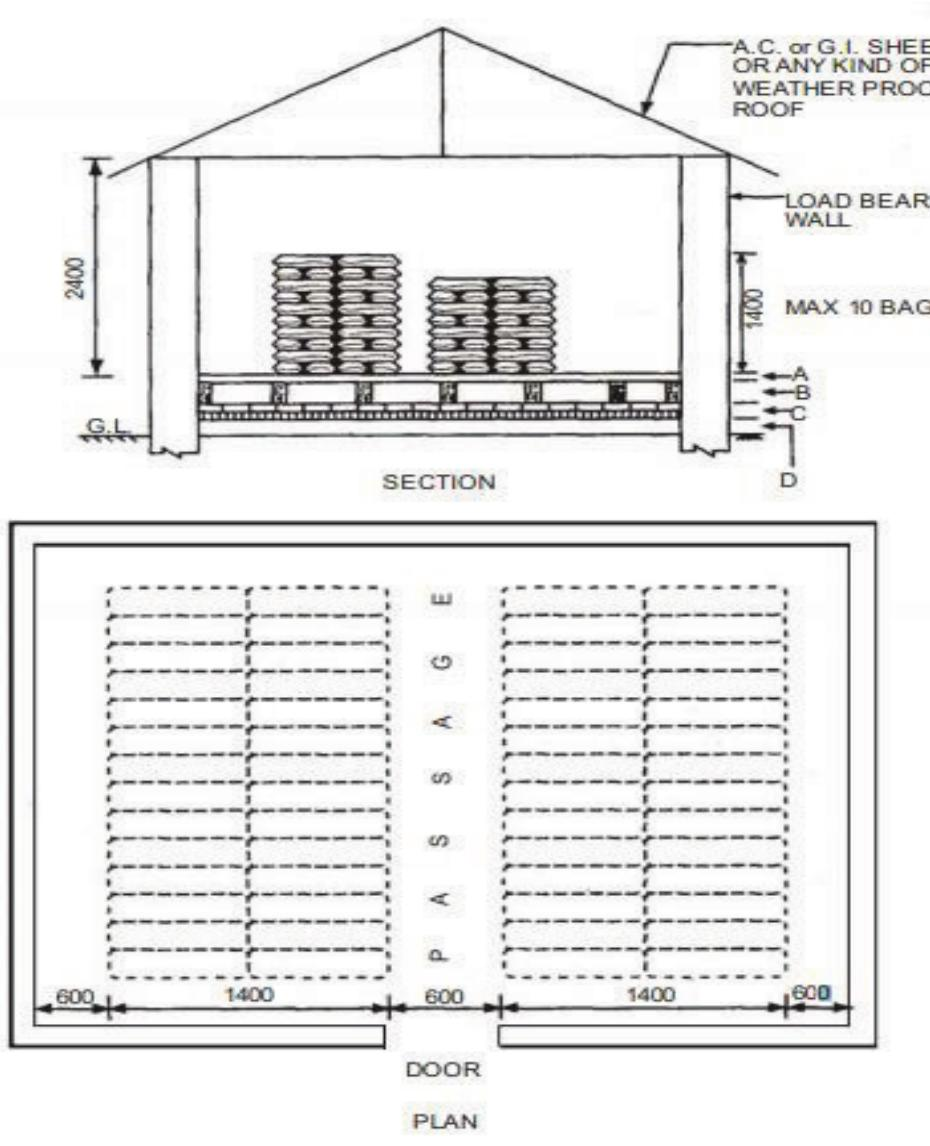

In [23]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[0])

In [26]:
print(texts[0])

CONTENTS

Clause No. Brief Description List of Bureau of Indian Standard Codes General Responsibility for Loss or Damage Mode of Carriage Lead General Consideration for Stacking and Storage Protection against Atmospheric Agencies 1.6 Protection against fire and other Hazards 1.7 to 1.26 Stacking and Storage of Materials 15 - 20 1.27 Measurements 1.28 Rate Table 1.1 Storage and Stacking Check List Fig. 1.1 Typical Sketch for Cement Godown 23

11 SUB HEAD 1.0 : CARRIAGE OF MATERIALS

LIST OF BUREAU OF INDIAN STANDARD CODES

S. No. I. S. No. Subject 1. IS 4082 Stacking & storage of construction materials and components at site - Recommendations IS 1141 Seasoning of Timber — Code of Practice

13 SUB HEAD 1.0 : CARRIAGE OF MATERIALS

1.0 CARRIAGE OF MATERIALS

1.0 GENERAL

The carriage and stacking of materials shall be done as directed by the Engineer-in- Charge. Any tools and plants, required for the work shall be arranged by the Contractor. The carriage of materials includes loading with

## Summarize the data

Create a summary of each element extracted from the PDF. This summary will be vectorized and used in the retrieval process.

### Text and Table summaries

We don't need a multimodal model to generate the summaries of the tables and the text. I will use open source models available on Groq.

In [30]:
%pip install -Uq langchain-groq

In [31]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [32]:
# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
model = ChatGroq(temperature=0.5, model="llama-3.1-8b-instant")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [33]:
# Summarize text
text_summaries = summarize_chain.batch(texts, {"max_concurrency": 3})

# Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_chain.batch(tables_html, {"max_concurrency": 3})

In [34]:
text_summaries

['The document outlines guidelines for the carriage and stacking of materials, including responsibility for loss or damage, mode of carriage, and lead distances. The Engineer-in-Charge is responsible for determining the mode of carriage and ensuring materials are stacked and stored safely.',
 'Storage layout planning is crucial for effective stacking and storage of materials, components, and equipment at construction sites, considering accessibility and manoeuvrability. Materials should be stored to prevent deterioration and preserve quality. Protection against atmospheric agencies, fire, and other hazards is also essential, with specific guidelines for storing materials like timber, coal, paints, and glass sheets.',
 'Pipes and fittings should be stored on firm, level ground, protected from heat, light, and grease, and stacked in a pyramid shape or alternating layers to prevent damage. Specific storage requirements vary by material type, with cast iron and asbestos cement pipes needin

### Image summaries

We will use gpt-4o-mini to produce the image summaries.

In [38]:
%pip install -Uq langchain_openai

In [39]:
# from langchain_openai import ChatOpenAI

# prompt_template = """Describe the image in detail. For context,
#                   the image is part of a book that gives the information about different materials. Be specific about graphs, such as bar plots."""
# messages = [
#     (
#         "user",
#         [
#             {"type": "text", "text": prompt_template},
#             {
#                 "type": "image_url",
#                 "image_url": {"url": "data:image/jpeg;base64,{image}"},
#             },
#         ],
#     )
# ]

# prompt = ChatPromptTemplate.from_messages(messages)

# chain = prompt | ChatOpenAI(model="gpt-4o-mini") | StrOutputParser()


# image_summaries = chain.batch(images)

In [103]:
from langchain_google_genai import ChatGoogleGenerativeAI


prompt_template = """Describe the image in detail. For context,
                  the image is part of a book that gives the information about different materials. Be specific about graphs, such as bar plots."""
messages = [
    (
        "user",
        [
            {"type": "text", "text": prompt_template},
            {
                "type": "image_url",
                "image_url": {"url": "data:image/jpeg;base64,{image}"},
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

chain = prompt | ChatGoogleGenerativeAI(model="gemini-2.5-flash") | StrOutputParser()


image_summaries = chain.batch(images)

In [105]:
image_summaries

['This image is a technical drawing or schematic diagram illustrating the design and layout for the storage of bagged materials, likely in a warehouse or shed, as part of a book about different materials. The drawing is composed of two main views: a "SECTION" view at the top and a "PLAN" view at the bottom.\n\n**Overall Description:**\nThe image depicts a storage structure designed to protect materials from the ground and weather, with specific dimensions and arrangements for stacking bags. It emphasizes proper ventilation and load-bearing considerations. There are no graphs or bar plots present in this image; it is purely an architectural/engineering diagram.\n\n---\n\n**Top Half: "SECTION" View**\n\nThis view presents a cross-section of the storage building, showing its internal structure and how materials are stored.\n\n*   **Building Structure:**\n    *   It features a gable roof, labeled as "A.C. or G.I. SHEET OR ANY KIND OF WEATHER PROOF ROOF," indicating that the roof should be 

In [104]:
print(image_summaries[0])

This image is a technical drawing or schematic diagram illustrating the design and layout for the storage of bagged materials, likely in a warehouse or shed, as part of a book about different materials. The drawing is composed of two main views: a "SECTION" view at the top and a "PLAN" view at the bottom.

**Overall Description:**
The image depicts a storage structure designed to protect materials from the ground and weather, with specific dimensions and arrangements for stacking bags. It emphasizes proper ventilation and load-bearing considerations. There are no graphs or bar plots present in this image; it is purely an architectural/engineering diagram.

---

**Top Half: "SECTION" View**

This view presents a cross-section of the storage building, showing its internal structure and how materials are stored.

*   **Building Structure:**
    *   It features a gable roof, labeled as "A.C. or G.I. SHEET OR ANY KIND OF WEATHER PROOF ROOF," indicating that the roof should be made of asbest

## Load data and summaries to vectorstore

In [88]:
!pip install langchain==0.3.27

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.8/450.8 kB 32.2 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.1.0
    Uninstalling langchain-core-1.1.0:
      Successfully uninstalled langchain-core-1.1.0
  Attempting uninstall: langchain-text-splitters
    Found existing installation: langchain-text-splitters 1.0.0
    Uninstalling langchain-text-splitters-1.0.0:
      Successfully uninstalled langchain-text-splitters-1.0.0
  Attempting uninstall: langchain
    Found existing installation: langchain 1.0.8
    Uninstalling langchain-1.0.8:
      Successfully uninstalled langchain-1.0.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-openai 1.0.3 requires langchain-core<2.0.0,>=1.0.2, but you have langchain-core 0.3.8

### Create the vectorstore

In [89]:
from langchain.retrievers.multi_vector import MultiVectorRetriever

In [90]:
import uuid
from langchain_chroma import Chroma
from langchain_core.stores import InMemoryStore
from langchain_core.documents import Document
from langchain.embeddings import OpenAIEmbeddings
from langchain.retrievers.multi_vector import MultiVectorRetriever

# # The vectorstore to use to index the child chunks
# vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=OpenAIEmbeddings())

# # The storage layer for the parent documents
# store = InMemoryStore()
# id_key = "doc_id"

# # The retriever (empty to start)
# retriever = MultiVectorRetriever(
#     vectorstore=vectorstore,
#     docstore=store,
#     id_key=id_key,
# )

In [45]:
!pip install langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.6 MB/s eta 0:00:00
  Attempting uninstall: google-ai-generativelanguage
    Found existing installation: google-ai-generativelanguage 0.6.15
    Uninstalling google-ai-generativelanguage-0.6.15:
      Successfully uninstalled google-ai-generativelanguage-0.6.15
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-generativeai 0.8.5 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.9.0 which is incompatible.


In [91]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings  # New import

# Set up Google embeddings (you need your API key set via environment variable or direct argument)
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001"
    # Optionally: api_key="YOUR_GOOGLE_API_KEY"
)

# The vectorstore to use to index the child chunks
vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=embeddings)

# The storage layer for the parent documents
store = InMemoryStore()
id_key = "doc_id"

# The retriever (empty to start)
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

### Load the summaries and link the to the original data

In [96]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)
retriever.docstore.mset(list(zip(doc_ids, texts)))

# Add tables
# table_ids = [str(uuid.uuid4()) for _ in tables]
# summary_tables = [
#     Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
# ]
# retriever.vectorstore.add_documents(summary_tables)
# retriever.docstore.mset(list(zip(table_ids, tables)))

# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)
retriever.docstore.mset(list(zip(img_ids, images)))

### Check retrieval

In [98]:
# Retrieve
docs = retriever.invoke(
    "What is the maximum height allowed for stacking materials during storage to avoid fire hazards?"
)

In [99]:
for doc in docs:
    print(str(doc) + "\n\n" + "-" * 80)

1.4 GENERAL CONSIDERATION FOR STACKING AND STORAGE

1.4.1 Planning of Storage Layout

For any site, there should be proper planning of the layout for stacking and storage of different materials, components and equipments with proper access and proper manoeuvrability of the vehicles carrying the material. While planning the layout, the requirements of various materials, components and equipments at different stages of construction shall be considered. The storage & stacking check list is given in Table 1.1. For further details refer IS- 4082.

1.4.2 Material shall be stored in such a manner as to prevent deterioration or intrusion of foreign matter and to ensure the preservation of their quality and fitness for the work.

1.5 PROTECTION AGAINST ATMOSPHERIC AGENCIES

Materials stored at site, depending upon the individual characteristics, shall be protected from atmospheric actions, such as rain, sun, winds and moisture to avoid deterioration.

1.6 PROTECTION AGAINST FIRE AND OTHER HAZAR

## RAG pipeline

In [100]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
# from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from base64 import b64decode


def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception as e:
            text.append(doc)
    return {"images": b64, "texts": text}


def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            context_text += text_element.text

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{image}"},
                }
            )

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )


chain = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatGoogleGenerativeAI(model="gemini-2.5-flash")
    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatGoogleGenerativeAI(model="gemini-2.5-flash")
        | StrOutputParser()
    )
)

In [101]:
response = chain.invoke(
    "What is the maximum height allowed for stacking materials during storage to avoid fire hazards?"
)

print(response)

To avoid fire hazards, stacks shall not be more than 4.5 m in height.


Response: According to the typical sketch for a cement godown, the materials used below the planks (A) to form the base are:
*   **B = Wooden Battens**
*   **C = 150 Dry Bricks in two Layers or Lean Cement Concrete**
*   **D = 150 Consolidated Earth**


Context:
TYPICAL SKETCH FOR CEMENT GODOWN

Sub Head : Carriage Clause : 1.7.1.2

AC_orGi. SHEET OR ANY KIND OF WEATHER PROOF ROOF OAD BEARING (ALL MAX 10 BAGS DOOR PLAN

A= Planks

B = Wooden Battens C = 150 Dry Bricks in two Layers or Lean Cement Concrete

D = 150 Consolidated Earth

Drawing not to scale All Dimensions in millimetres

Fig. 1.1 : Typical Arrangement in Cement Godown

23 SUB HEAD 1.0 : CARRIAGE OF MATERIALS
Page number:  9

--------------------------------------------------

TYPICAL SKETCH FOR CEMENT GODOWN

Sub Head : Carriage Clause : 1.7.1.2

AC_orGi. SHEET OR ANY KIND OF WEATHER PROOF ROOF OAD BEARING (ALL MAX 10 BAGS DOOR PLAN

A= Planks

B = Wooden Battens C = 150 Dry Bricks in two Layers or Lean Cement Concrete

D

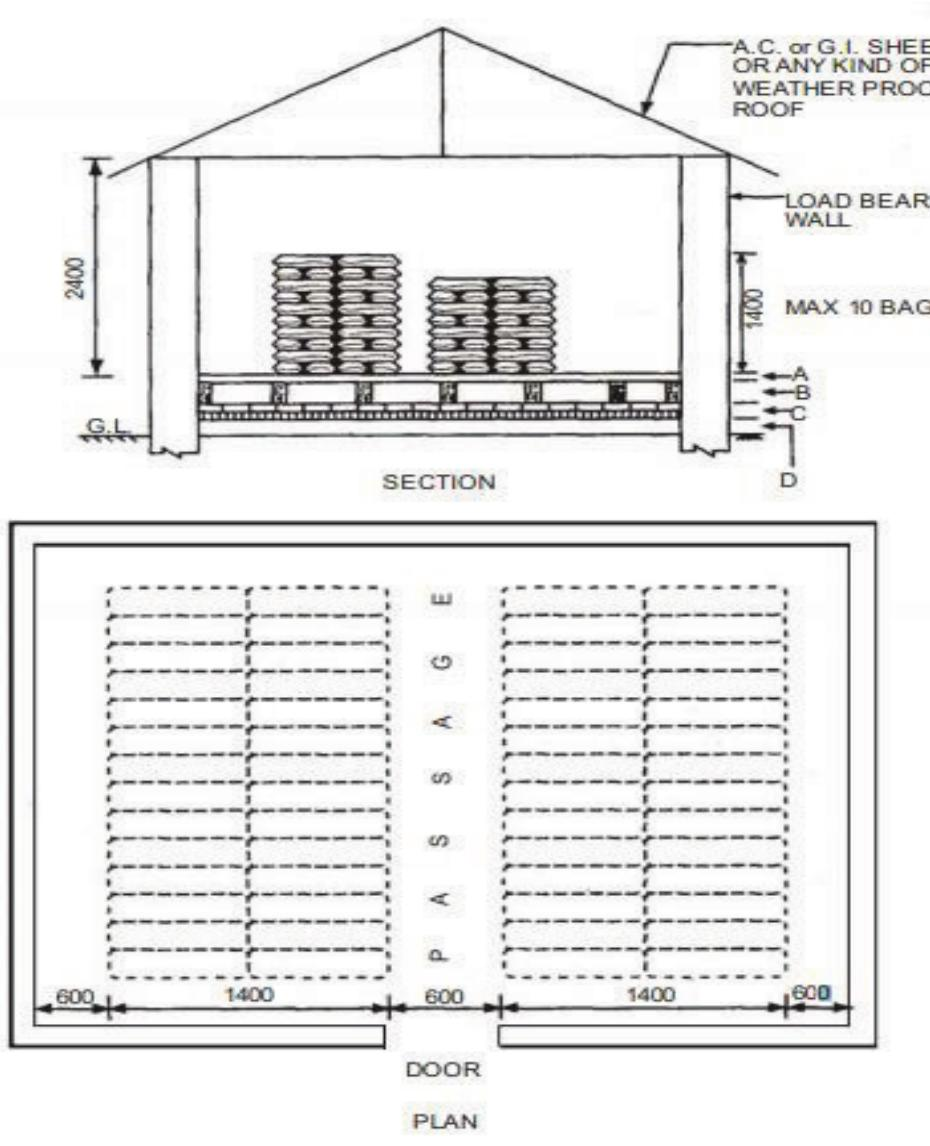

In [102]:
response = chain_with_sources.invoke(
    "According to the typical sketch for a cement godown, what materials are used below the planks to form the base?"
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    print(text.text)
    print("Page number: ", text.metadata.page_number)
    print("\n" + "-"*50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)

## References

- [LangChain Inspiration](https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb?ref=blog.langchain.dev)
- [Multivector Storage](https://python.langchain.com/docs/how_to/multi_vector/)